# Part 3: Multi-Backend Execution — The Bernstein-Vazirani Algorithm

In this notebook, we implement the **Bernstein-Vazirani (BV) algorithm** and execute it across multiple quantum hardware providers available through qBraid. This showcases qBraid's ability to seamlessly target different backends with the same circuit.

### Learning Objectives

1. Understand the Bernstein-Vazirani algorithm and its quantum speedup
2. Build the BV circuit in Qiskit
3. Verify correctness on a simulator
4. Execute the same circuit on QPU backends from Rigetti and IQM
5. Compare results across different quantum hardware providers

In [1]:
import warnings
warnings.filterwarnings("ignore")

from qiskit import QuantumCircuit
from qbraid.runtime import QbraidProvider
from qbraid.visualization import plot_histogram

## The Bernstein-Vazirani Algorithm

### The Problem

You are given a black-box function (oracle) that computes:

$$ f(x) = s \cdot x \mod 2 $$

where $s$ is a **secret bitstring** and $s \cdot x$ is the bitwise dot product (e.g., for $s = 1011$ and $x = 1100$: $s \cdot x = 1{\cdot}1 + 0{\cdot}1 + 1{\cdot}0 + 1{\cdot}0 = 1$).

**Goal:** Find the secret string $s$.

### Classical vs Quantum

| Approach | Queries needed |
|---|---|
| **Classical** | $n$ queries (try each bit position one at a time) |
| **Quantum (BV)** | **1 query** (all bit positions determined simultaneously) |

This is an exponential-style speedup: the quantum algorithm solves the problem in a single oracle call, regardless of the string length.

### How the Circuit Works

1. **Initialize:** $n$ input qubits in $|0\rangle$ + 1 ancilla qubit in $|1\rangle$
2. **Apply Hadamard** to all qubits — creates uniform superposition on inputs, $|{-}\rangle$ on ancilla
3. **Apply Oracle** — for each bit $s_i = 1$, apply CNOT from qubit $i$ to the ancilla
4. **Apply Hadamard** again to input qubits
5. **Measure** input qubits — the result is exactly $s$!

The math works out because the Hadamard-Oracle-Hadamard sequence causes constructive interference on the $|s\rangle$ state and destructive interference on all others.

## Building the BV Circuit

We'll use the secret string $s = 1011$ (4 qubits). The circuit uses 5 qubits total (4 input + 1 ancilla).

In [14]:
# Secret string to find
secret = "1011"
n = len(secret)

# Create circuit: n input qubits + 1 ancilla, n classical bits
bv_circuit = QuantumCircuit(n + 1, n)

# Step 1: Initialize ancilla in |-> state
bv_circuit.x(n)
bv_circuit.h(n)

# Step 2: Apply Hadamard to all input qubits
for i in range(n):
    bv_circuit.h(i)

bv_circuit.barrier()

# Step 3: Oracle — apply CNOT for each bit of s that is '1'
for i, bit in enumerate(reversed(secret)):
    if bit == "1":
        bv_circuit.cx(i, n)

bv_circuit.barrier()

# Step 4: Apply Hadamard to input qubits again
for i in range(n):
    bv_circuit.h(i)

# Step 5: Measure input qubits
for i in range(n):
    bv_circuit.measure(i, i)

print(f"Secret string: {secret}")
print(f"Circuit depth: {bv_circuit.depth()}, Qubits: {bv_circuit.num_qubits}")

Secret string: 1011
Circuit depth: 7, Qubits: 5


In [15]:
print(bv_circuit)

     ┌───┐      ░                 ░ ┌───┐┌─┐         
q_0: ┤ H ├──────░───■─────────────░─┤ H ├┤M├─────────
     ├───┤      ░   │             ░ ├───┤└╥┘┌─┐      
q_1: ┤ H ├──────░───┼────■────────░─┤ H ├─╫─┤M├──────
     ├───┤      ░   │    │        ░ ├───┤ ║ └╥┘┌─┐   
q_2: ┤ H ├──────░───┼────┼────────░─┤ H ├─╫──╫─┤M├───
     ├───┤      ░   │    │        ░ ├───┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░───┼────┼────■───░─┤ H ├─╫──╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░─┤ X ├┤ X ├┤ X ├─░───────╫──╫──╫──╫─
     └───┘└───┘ ░ └───┘└───┘└───┘ ░       ║  ║  ║  ║ 
c: 4/═════════════════════════════════════╩══╩══╩══╩═
                                          0  1  2  3 


---

## Step 1: Verify on Simulator

Before running on real hardware, let's confirm the circuit works correctly on the AWS SV1 simulator. We should recover the secret string `1011` with 100% probability.

In [16]:
provider = QbraidProvider()
aws_sim = provider.get_device("aws:aws:sim:sv1")
aws_sim

<qbraid.runtime.native.device.QbraidDevice('aws:aws:sim:sv1')>

In [17]:
sim_job = aws_sim.run(bv_circuit, shots=100)
sim_counts = sim_job.result().data.get_counts()
print(f"Simulator counts: {sim_counts}")
print(f"Secret string recovered: {max(sim_counts, key=sim_counts.get)}")

Simulator counts: {'1011': 100}
Secret string recovered: 1011


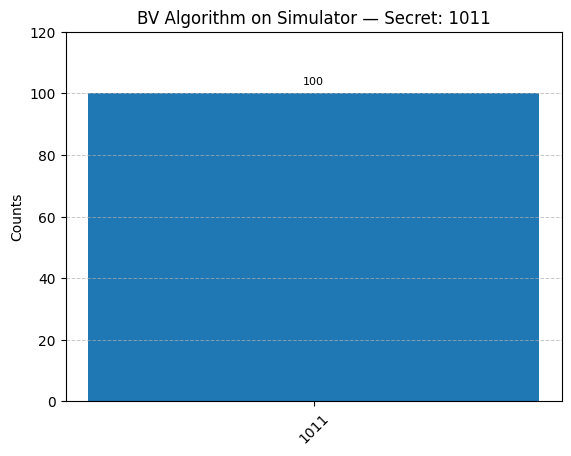

In [18]:
plot_histogram(sim_counts, title=f"BV Algorithm on Simulator — Secret: {secret}")

The simulator recovers the secret string `1011` with 100% probability, confirming our circuit is correct. Now let's see how real hardware performs.

---

## Step 2: Multi-Backend QPU Execution

qBraid provides access to quantum computers from multiple vendors. We'll run the BV circuit on two devices from different providers:

| Provider | Device | Technology | Qubits |
|---|---|---|---|
| **Rigetti** | Ankaa-3 | Superconducting | 84 |
| **IQM** | Garnet | Superconducting | 20 |

Both use superconducting technology, but differences in chip architecture, qubit connectivity, and calibration quality will produce different noise profiles.

In [19]:
# Show all available devices and their metadata
all_devices = provider.get_devices()

print(f"{'Device ID':<45} {'Provider':<15} {'Type':<10} {'Status':<12} {'Qubits'}")
print("-" * 95)
for d in all_devices:
    meta = d.metadata()
    if meta.get("status") == "ONLINE" and meta.get("simulator") == False:
        dev_type = "Simulator" if meta.get("simulator") else "QPU"
        print(f"{meta['device_id']:<45} {meta.get('provider_name', 'N/A'):<15} {dev_type:<10} {meta.get('status', 'N/A'):<12} {meta.get('num_qubits', 'N/A')}")

Device ID                                     Provider        Type       Status       Qubits
-----------------------------------------------------------------------------------------------
aws:quera:qpu:aquila                          quera           QPU        ONLINE       256
azure:rigetti:qpu:ankaa-3                     rigetti         QPU        ONLINE       84
aws:ionq:qpu:forte-enterprise-1               ionq            QPU        ONLINE       36
aws:iqm:qpu:garnet                            iqm             QPU        ONLINE       20
azure:rigetti:qpu:cepheus-1-36q               rigetti         QPU        ONLINE       36
azure:ionq:qpu:forte-enterprise-1             ionq            QPU        ONLINE       36


---

### Rigetti Ankaa-3 (Superconducting)

Rigetti uses **superconducting** transmon qubits — circuits cooled to near absolute zero (~15 millikelvin). This approach offers:
- Very fast gate speeds (nanosecond-scale)
- Larger qubit counts
- Limited connectivity (nearest-neighbor topology)
- Shorter coherence times compared to trapped ions

In [20]:
rigetti_device = provider.get_device("aws:rigetti:qpu:ankaa-3")
rigetti_device.metadata()

{'device_id': 'aws:rigetti:qpu:ankaa-3',
 'simulator': False,
 'num_qubits': 84,
 'provider_name': 'rigetti',
 'basis_gates': None,
 'name': 'Ankaa-3 (AWS)',
 'pricing': {'perTask': 30.0, 'perShot': 0.09, 'perMinute': 0.0},
 'queue_depth': 0,
 'status': 'UNAVAILABLE',
 'paradigm': 'gate_model',
 'runtime_config': {'target_program_type': ['braket', 'qasm3'],
  'conversion_scheme': {'conversion_graph': None,
   'max_path_attempts': 3,
   'max_path_depth': None},
  'options': {'transpile': True,
   'transform': True,
   'validate': 2,
   'prepare': True}}}

> **WARNING: The cell below executes on REAL quantum hardware (Rigetti Ankaa-3).** Review pricing above before running.

In [21]:
num_shots = 100  # Review device pricing before increasing
rigetti_job = rigetti_device.run(bv_circuit, shots=num_shots)
print(rigetti_job)

<QbraidJob(id:'aws:rigetti:qpu:ankaa-3-ae17-qjob-69d8a0b2ae01710b137544d2')>


In [ ]:
rigetti_counts = rigetti_job.result().data.get_counts()
print(f"Rigetti counts: {rigetti_counts}")
print(f"Most frequent result: {max(rigetti_counts, key=rigetti_counts.get)}")

---

### IQM Garnet (Superconducting)

IQM is a European quantum computing company that also uses **superconducting** technology. Comparing IQM and Rigetti results will let us see how different superconducting implementations perform on the same algorithm.

In [23]:
iqm_device = provider.get_device("aws:iqm:qpu:garnet")
iqm_device.metadata()

{'device_id': 'aws:iqm:qpu:garnet',
 'simulator': False,
 'num_qubits': 20,
 'provider_name': 'iqm',
 'basis_gates': None,
 'name': 'Garnet',
 'pricing': {'perTask': 30.0, 'perShot': 0.145, 'perMinute': 0.0},
 'queue_depth': 0,
 'status': 'ONLINE',
 'paradigm': 'gate_model',
 'runtime_config': {'target_program_type': ['braket', 'qasm3'],
  'conversion_scheme': {'conversion_graph': None,
   'max_path_attempts': 3,
   'max_path_depth': None},
  'options': {'transpile': True,
   'transform': True,
   'validate': 2,
   'prepare': True}}}

> **WARNING: The cell below executes on REAL quantum hardware (IQM Garnet).** Review pricing above before running.

In [24]:
num_shots = 100  # Review device pricing before increasing
iqm_job = iqm_device.run(bv_circuit, shots=num_shots)
print(iqm_job)

<QbraidJob(id:'aws:iqm:qpu:garnet-ae17-qjob-69d8a2c3ae01710b1375459f')>


In [25]:
iqm_counts = iqm_job.result().data.get_counts()
print(f"IQM counts: {iqm_counts}")
print(f"Most frequent result: {max(iqm_counts, key=iqm_counts.get)}")

IQM counts: {'0000': 1, '0011': 4, '1000': 1, '1001': 3, '1010': 1, '1011': 89, '1111': 1}
Most frequent result: 1011


---

## Step 3: Compare Results Across Backends

Let's visualize the results from all backends side by side. The secret string `1011` should be the most frequent outcome in every case, but the noise profiles will differ.

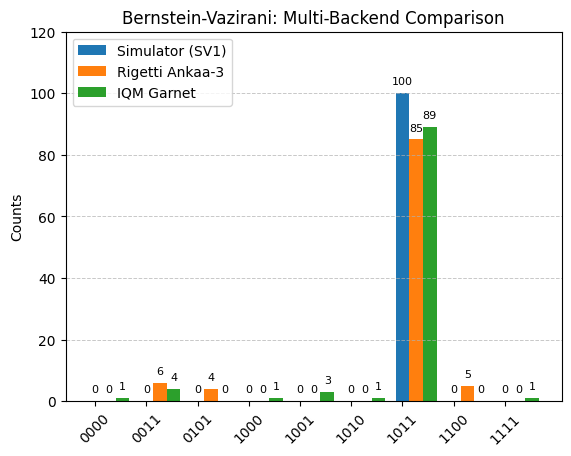

In [27]:
plot_histogram(
    [sim_counts, rigetti_counts, iqm_counts],
    legend=["Simulator (SV1)", "Rigetti Ankaa-3", "IQM Garnet"],
    title="Bernstein-Vazirani: Multi-Backend Comparison"
)

## Analysis

### What to Look For

1. **Correct answer dominance** — the secret string `1011` should be the most probable outcome on every device. If it isn't, that device has particularly high error rates for this circuit.

2. **Noise distribution** — how many "wrong" bitstrings appear, and how spread out the errors are. Fewer wrong answers = better hardware performance.

3. **Cross-vendor comparison** — Rigetti and IQM are both superconducting, but differences in chip architecture, qubit connectivity, and calibration quality will show up in the noise profiles.

4. **Success probability** — what fraction of shots returned the correct secret string? This is a practical measure of each device's quality for this specific circuit.

### Key Question

Even with noise, does every device still correctly identify `1011` as the *most probable* outcome? This is the practical threshold: as long as the correct answer has the highest probability, we can use **majority voting** across multiple shots to reliably extract the answer.

---

## Key Takeaways

1. **One circuit, many backends** — qBraid lets you write a circuit once and run it on any supported quantum device, regardless of the vendor.

2. **Bernstein-Vazirani demonstrates quantum speedup** — finding the secret string classically requires $n$ queries, but the quantum algorithm needs just 1. Even with hardware noise, the correct answer dominates.

3. **Different hardware, different noise** — even though Rigetti and IQM both use superconducting qubits, their different chip architectures and calibration produce distinct noise profiles.

4. **qBraid simplifies multi-provider access** — instead of learning each provider's SDK separately, qBraid provides a single API:
   ```python
   device = provider.get_device("cloud:vendor:type:name")
   job = device.run(circuit, shots=N)
   counts = job.result().data.get_counts()
   ```

5. **Hardware is improving rapidly** — as quantum computers get better, the noise will decrease and algorithms like BV will succeed with even higher fidelity.